## Initial Visualization


In [1]:
state="MA"

In [2]:
#sc.stop()

In [3]:
import pandas as pd
import numpy as np
import sklearn as sk

In [4]:
import matplotlib

In [5]:
%%time
%run lib/startup.py S

sc_type= S
10.41.226.219
namespace= grader-cse255-01
driver_host= 10.41.226.219


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


25/04/30 18:31:35 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
sparkContext= <SparkContext master=spark://spark-master-0.spark-headless.grader-cse255-01.svc.cluster.local:7077 appName=myapp>



/opt/bitnami/spark/python/pyspark/sql/context.py:112: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


version of ipwidgets= 8.1.6
parquet_root= /home/grader-cse255-01/public/Data/weather


measurements is a Dataframe (and table) with 12720632 records
stations is a Dataframe (and table) with 119503 records


weather is a Dataframe (and table) which is a join of measurements and stations with 12720632 records
CPU times: user 602 ms, sys: 116 ms, total: 719 ms
Wall time: 53 s


In [6]:
import warnings  # Suppress Warnings
warnings.filterwarnings('ignore')

_figsize=(10,7)

In [7]:
parquet_root

'/home/grader-cse255-01/public/Data/weather'

In [8]:
ms=['TMAX', 'SNOW', 'SNWD', 'TMIN', 'PRCP', 'TOBS']
cms='or\n'.join(['Measurement="%s" '%(m) for m in ms])

##  read all data for state
Query="""
SELECT *
FROM weather
WHERE state="%s" and 
(%s)
"""%(state,cms)
print(Query)


SELECT *
FROM weather
WHERE state="MA" and 
(Measurement="TMAX" or
Measurement="SNOW" or
Measurement="SNWD" or
Measurement="TMIN" or
Measurement="PRCP" or
Measurement="TOBS" )



In [9]:
%%time
weather_df=sqlContext.sql(Query)
print('number of rows in result=',weather_df.count())
weather_df.show(2)

number of rows in result= 49710


+-----------+-----------+----+--------------------+--------+---------+---------+-------------+--------------------+-----+-------------+
|    Station|Measurement|Year|              Values|latitude|longitude|elevation|   dist2coast|                name|state|      country|
+-----------+-----------+----+--------------------+--------+---------+---------+-------------+--------------------+-----+-------------+
|US1MABA0017|       PRCP|2022|[00 00 77 00 00 0...| 41.5828| -70.5803|     12.8| 0.9072265625|EAST FALMOUTH 1.2...|   MA|United States|
|US1MABA0018|       SNOW|2022|[00 00 00 00 19 F...| 41.5818| -70.5257|      9.8|0.94091796875|     WAQUOIT 0.6 SSW|   MA|United States|
+-----------+-----------+----+--------------------+--------+---------+---------+-------------+--------------------+-----+-------------+
only showing top 2 rows

CPU times: user 17.5 ms, sys: 624 µs, total: 18.1 ms
Wall time: 7.37 s


In [10]:
%load_ext autoreload
%autoreload 2 

### read or compute statistics information for state.

In [11]:
%%time
import os.path
from lib.computeStatistics import computeStatistics
from pickle import dump,load

pkl_filename=parquet_root+'/weather-statistics/'+state+'-'+','.join(ms)+'.pkl'
print(pkl_filename)
!ls $pkl_filename

/home/grader-cse255-01/public/Data/weather/weather-statistics/MA-TMAX,SNOW,SNWD,TMIN,PRCP,TOBS.pkl
/home/grader-cse255-01/public/Data/weather/weather-statistics/MA-TMAX,SNOW,SNWD,TMIN,PRCP,TOBS.pkl
CPU times: user 5.88 ms, sys: 14.6 ms, total: 20.5 ms
Wall time: 401 ms


In [12]:
import lib.computeStatistics

In [13]:
if os.path.isfile(pkl_filename):   
    print('precomputed statistics file exists')
    with open(pkl_filename,'br') as pkl_file:
        STAT=load(pkl_file)
else:
    print('need to compute statistics')
STAT.keys()

precomputed statistics file exists


dict_keys(['TMAX', 'SNOW', 'SNWD', 'TMIN', 'PRCP', 'TOBS'])

### print statistics 

In [14]:
import numpy
S=STAT['SNOW']
for key in ['mean', 'std', 'low100', 'high100']:
    element=S[key]
    print(key,'=',end='')
    if type(element)==numpy.float64 or type(element)==numpy.float16:
        print('%6.2f'%element)
    elif type(element)==numpy.ndarray:
        print (element)
    else:
        print('unidentified type=',type(element))

mean =  4.47
std = 47.08
low100 =  0.00
high100 =152.00


%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


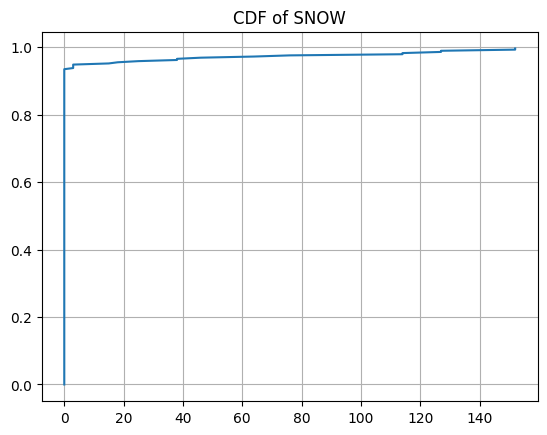

In [15]:
%pylab inline
measurement='SNOW'
Sobs=STAT[measurement]['SortedVals']

#figure(figsize=[15,10])
n_obs=Sobs.shape[0]
p=arange(0,1,1/n_obs)
plot(Sobs,p)
title('CDF of '+measurement)
grid()

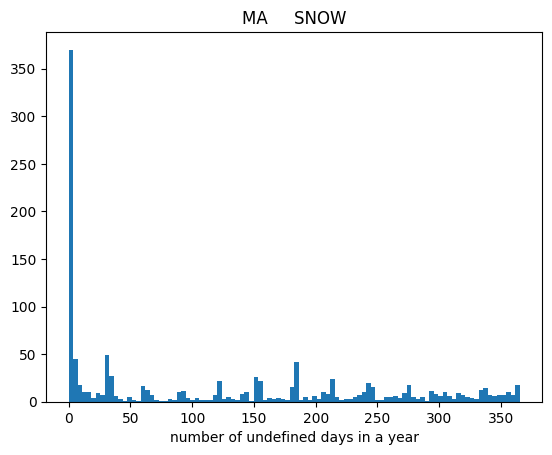

In [16]:
## distribution of undefined elements in yearly measurements.
hist(S['UnDef'],bins=100);
xlabel('number of undefined days in a year');
title(state+'     '+measurement);

In [17]:
%%time
## Find the number of measurements of each of the common 6 types in MA

Query="""
select Measurement,count(Measurement) as count
from weather
WHERE state='%s'
GROUP BY Measurement
ORDER BY count DESC
"""%state
sqlContext.sql(Query).show(15)

+-----------+-----+
|Measurement|count|
+-----------+-----+
|       PRCP|12304|
|       SNOW|11379|
|       SNWD| 8750|
|       TMIN| 6524|
|       TMAX| 6502|
|       WT03| 4830|
|       TOBS| 4251|
|       WT01| 3707|
|       WT04| 3368|
|       MDPR| 2825|
|       DAPR| 2789|
|       WT06| 1962|
|       WT16| 1900|
|       WT05| 1775|
|       WT18| 1722|
+-----------+-----+
only showing top 15 rows

CPU times: user 4.25 ms, sys: 8.46 ms, total: 12.7 ms
Wall time: 4.86 s


In [18]:
!grep MDPR $parquet_root/noaa/readme.txt

	          total (MDPR)
	          multiday precipitation total (MDPR)
	   MDPR = Multiday precipitation total (tenths of mm; use with DAPR and 


In [19]:
!grep WT $parquet_root/noaa/readme.txt

	   WT** = Weather Type where ** has one of the following values:


In [20]:
## Find the number of measurements (years) for each station in state
Query="""
select Station,count(Station) as count
from weather
WHERE state='%s' and Measurement='TOBS'
GROUP BY Station
ORDER BY count DESC
"""%state
#print(Query)
tmp=sqlContext.sql(Query)
print(tmp.count())
tmp.show(3)

160


+-----------+-----+
|    Station|count|
+-----------+-----+
|USC00194105|  122|
|USC00193505|  120|
|USC00198367|  107|
+-----------+-----+
only showing top 3 rows



In [21]:
### show details of state
station="USC00194105"
Query="""
select * from stations
WHERE Station="%s"
"""%station
sqlContext.sql(Query).show()

+-----------+--------+---------+---------+----------+--------+-----+-------------+
|    station|latitude|longitude|elevation|dist2coast|    name|state|      country|
+-----------+--------+---------+---------+----------+--------+-----+-------------+
|USC00194105| 42.6992| -71.1658|     15.2| 27.859375|LAWRENCE|   MA|United States|
+-----------+--------+---------+---------+----------+--------+-----+-------------+



In [22]:
#find how many measurements of each type for a particlar station
Query="""
SELECT Measurement,count(Measurement) as count 
FROM weather
WHERE Station='%s' 
GROUP BY Measurement
ORDER BY count DESC
"""%station
sqlContext.sql(Query).show(8)

+-----------+-----+
|Measurement|count|
+-----------+-----+
|       TMAX|  130|
|       SNOW|  130|
|       PRCP|  130|
|       TMIN|  130|
|       TOBS|  122|
|       SNWD|   96|
|       MDPR|   49|
|       WT03|   49|
+-----------+-----+
only showing top 8 rows



In [23]:
%%time
#find year with all measurements
Query="""
SELECT Year,count(Year) as count 
FROM weather
WHERE Station='%s' 
GROUP BY Year
ORDER BY count DESC
"""%station
pdf=sqlContext.sql(Query).toPandas()

CPU times: user 29.7 ms, sys: 9.28 ms, total: 38.9 ms
Wall time: 5.1 s


In [24]:
pdf.head()

,Year,count
0,1926,15
1,1938,14
2,1943,14
3,1930,14
4,1936,14


In [25]:
# get all measurements for a particular year and a particular station
year=1945
Query="""
SELECT *
FROM weather
WHERE Year='%s' 
and Measurement='TOBS'
and State='%s'
"""%(year,state)
df=sqlContext.sql(Query)
print(df.count())
df.show(1)

35


+-----------+-----------+----+--------------------+--------+---------+---------+----------+--------------------+-----+-------------+
|    Station|Measurement|Year|              Values|latitude|longitude|elevation|dist2coast|                name|state|      country|
+-----------+-----------+----+--------------------+--------+---------+---------+----------+--------------------+-----+-------------+
|USW00014703|       TOBS|1945|[43 00 D4 FF A7 F...|    42.2| -72.5333|     75.0|   97.3125|CHICOPEE FALLS WE...|   MA|United States|
+-----------+-----------+----+--------------------+--------+---------+---------+----------+--------------------+-----+-------------+
only showing top 1 row



In [26]:
from numpy_pack import unpackAndScale

In [27]:
%%time

ListOfRows=df.rdd.map(lambda x: (x.Station,unpackAndScale(x))).collect()
_labels = [x[0] for x in ListOfRows]
M=stack([x[1] for x in ListOfRows])
M.shape
        

CPU times: user 20.1 ms, sys: 7.91 ms, total: 28 ms
Wall time: 3.39 s


(35, 366)

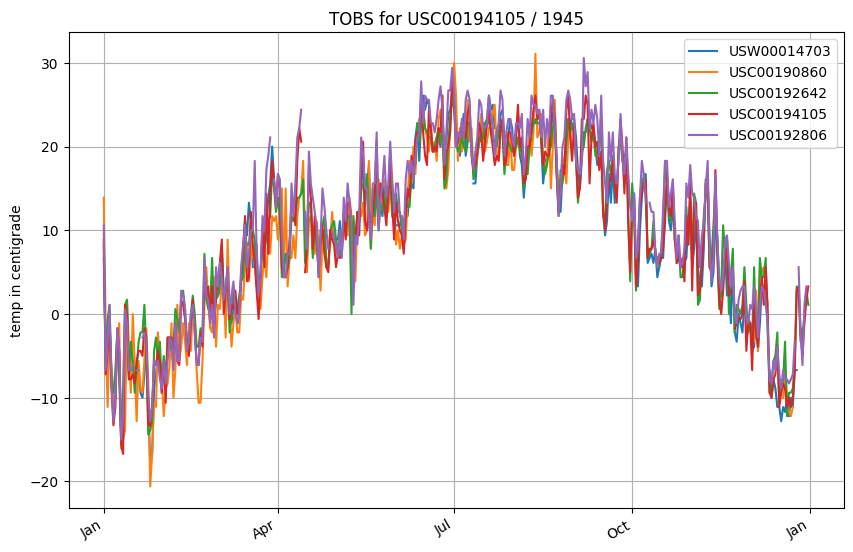

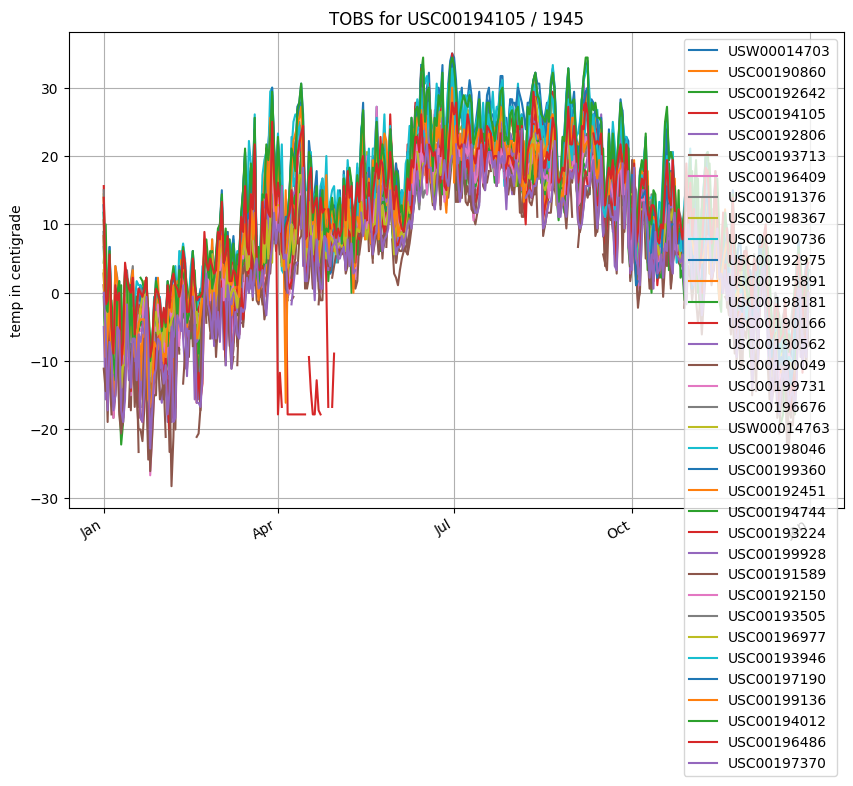

In [28]:
from lib.YearPlotter import YearPlotter
k=5
_title='TOBS for %s / %d'%(station,year)
fig, ax = plt.subplots(figsize=_figsize);
YP=YearPlotter()
YP.plot(M[:k,:366].T,fig,ax,title=_title,labels=_labels)# ,labels=labels);
ylabel('temp in centigrade');

#looking at all of the year creates a mess
from lib.YearPlotter import YearPlotter
k=35
fig, ax = plt.subplots(figsize=_figsize);
YP=YearPlotter()
YP.plot(M[:k,:366].T,fig,ax,title=_title,labels=_labels)# ,labels=labels);
ylabel('temp in centigrade');

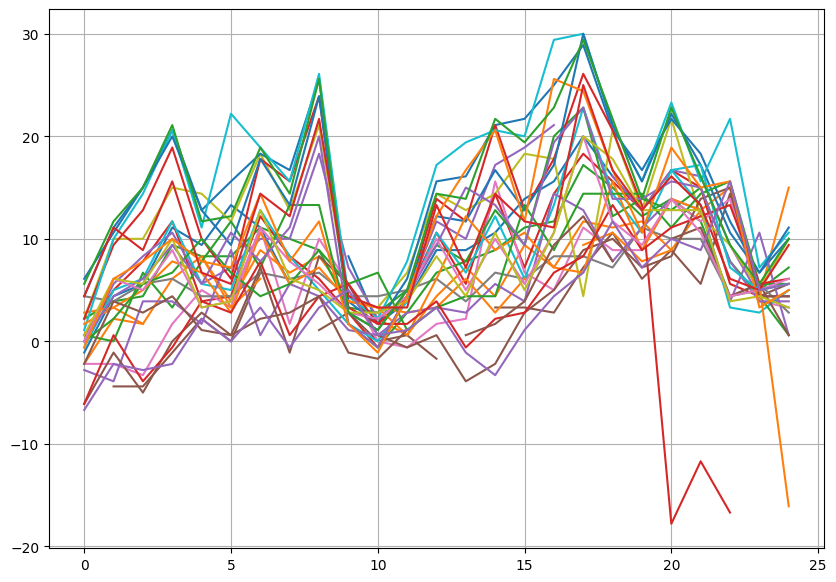

In [29]:
## Looking at a small range of days  across all stations in state reveals 
## Interesting clustering
figure(figsize=_figsize)
plot(M[:,70:95].transpose());
grid()

In [30]:
# get all measurements for a particular year and a particular station
Query="""
SELECT *
FROM weather
WHERE Station='%s' 
and Year=%d
"""%(station,year )
print(Query)
pandas_df=sqlContext.sql(Query).toPandas()
pandas_df=pandas_df.set_index('Measurement')
print('pandas_df.shape=',pandas_df.shape)
print('pandas_df.columns=',pandas_df.columns)


SELECT *
FROM weather
WHERE Station='USC00194105' 
and Year=1945



pandas_df.shape= (13, 10)
pandas_df.columns= Index(['Station', 'Year', 'Values', 'latitude', 'longitude', 'elevation',
       'dist2coast', 'name', 'state', 'country'],
      dtype='object')


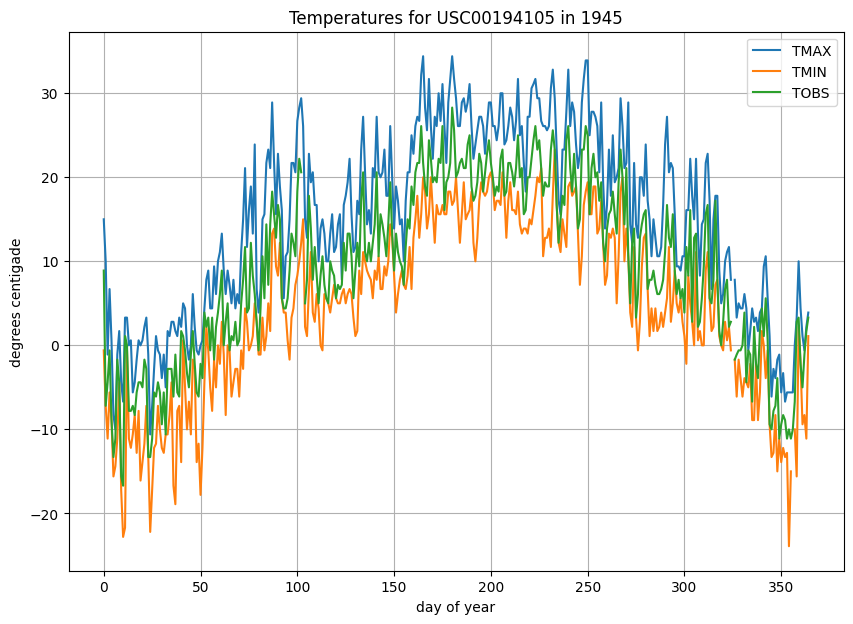

In [31]:
from numpy_pack import unpackArray
_tmax=unpackArray(pandas_df.loc['TMAX','Values'],np.int16)/10.
_tmin=unpackArray(pandas_df.loc['TMIN','Values'],np.int16)/10.
_tobs=unpackArray(pandas_df.loc['TOBS','Values'],np.int16)/10.
figure(figsize=_figsize)
plot(_tmax,label='TMAX');
plot(_tmin,label='TMIN');
plot(_tobs,label='TOBS');

xlabel('day of year')
ylabel('degrees centigade')
title('Temperatures for %s in %d'%(station,year))
legend()
grid()

### Script for plotting yearly plots

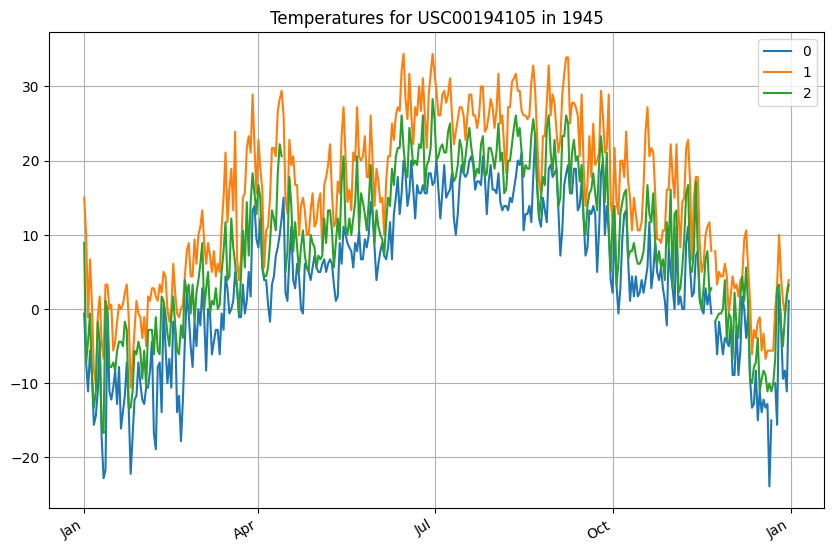

In [32]:
from lib.YearPlotter import YearPlotter
T=np.stack([_tmin,_tmax,_tobs])

fig, ax = plt.subplots(figsize=_figsize);
YP=YearPlotter()
YP.plot(T.transpose(),fig,ax,title='Temperatures for %s in %d'%(station,year));
plt.savefig('percipitation.png')
#title('A sample of graphs');

## Statistics across the state

### Distribution of missing observations
The distribution of missing observations is not uniform throughout the year. We visualize it below.

In [33]:
from lib.MultiPlot import *
YP=YearPlotter()
def plot_valid(m,fig,axis):
    valid_m=STAT[m]['NE']
    YP.plot(valid_m,fig,axis,title='valid-counts '+m,label=m)
    

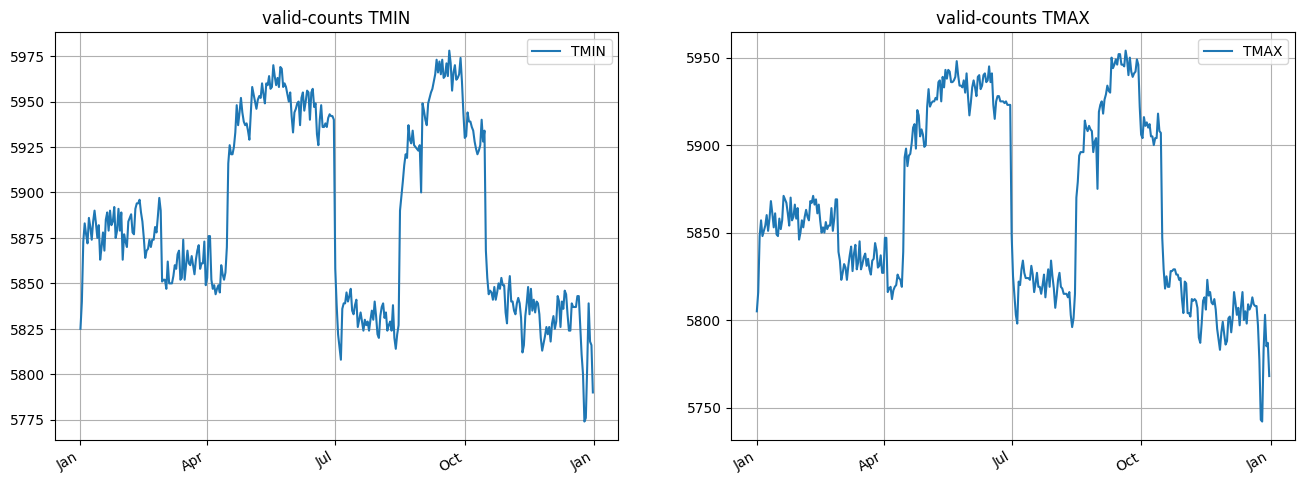

In [34]:
plot_pair(['TMIN','TMAX'],plot_valid)

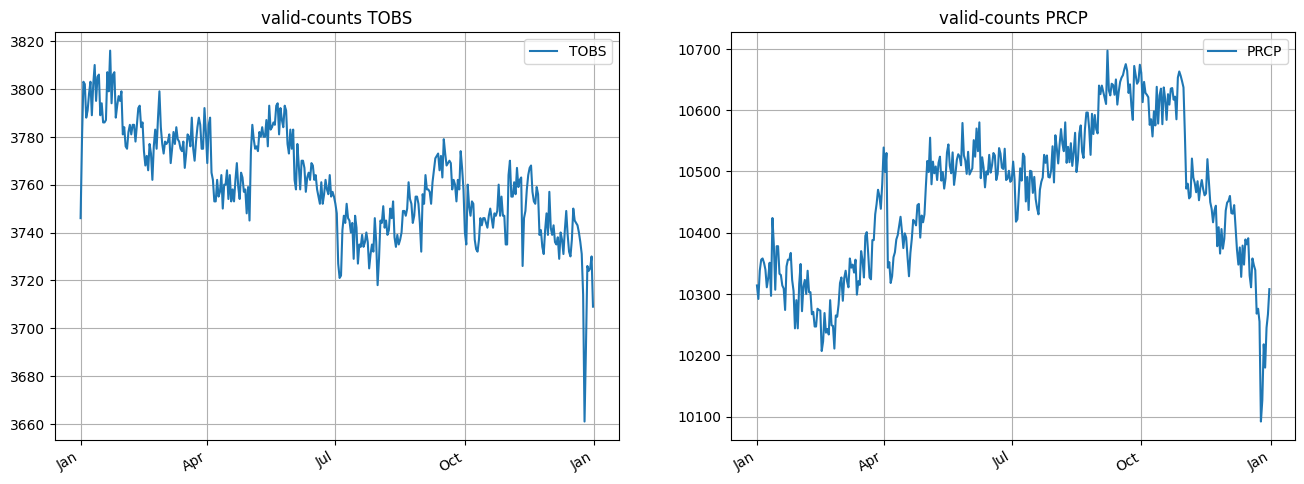

In [35]:
plot_pair(['TOBS','PRCP'],plot_valid)

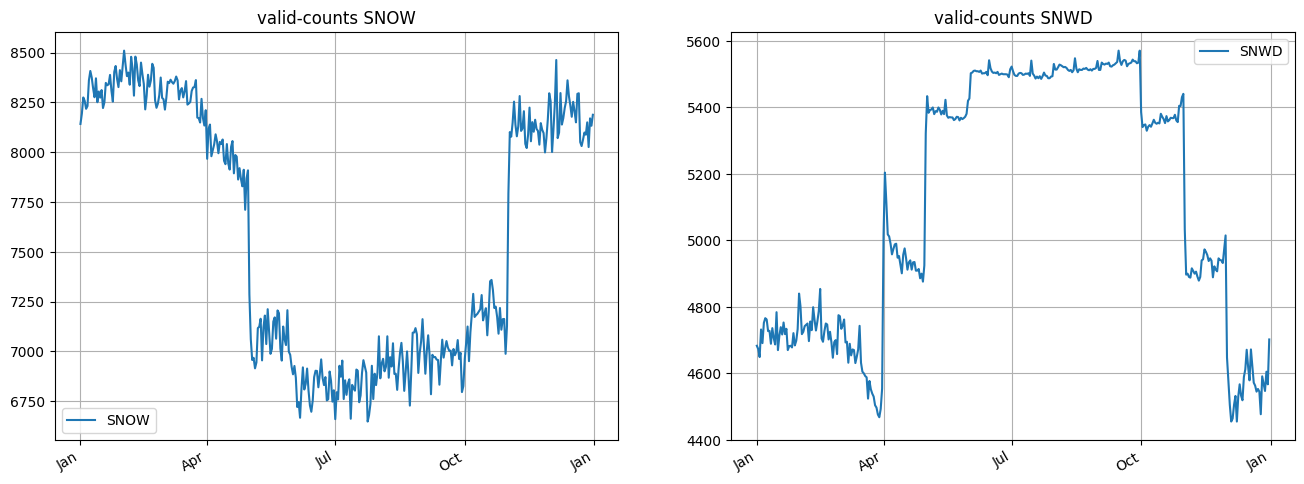

In [36]:
# Note that for "SNOW" there are more missing measurements in the summer
# While for SNWD there are less missing in the summer
# Question: do these anomalies involve the same stations?
plot_pair(['SNOW', 'SNWD'],plot_valid)

### Plots of mean and std of observations

In [37]:
def plot_mean_std(m,fig,axis):
    scale=1.
    temps=['TMIN','TMAX','TOBS']
    percipitation=['PRCP','SNOW','SNWD']
    _labels=['mean+std','mean','mean-std']
    if (m in percipitation):
        scale=10.
    mean=STAT[m]['Mean']/scale
    std=np.sqrt(STAT[m]['Var'])/scale
    graphs=np.vstack([mean+std,mean,mean-std]).transpose()
    YP.plot(graphs,fig,axis,labels=_labels,title='Mean+-std   '+m)
    if (m in temps):
        axis.set_ylabel('Degrees Celsius')
    if (m in percipitation):
        axis.set_ylabel('millimeter')



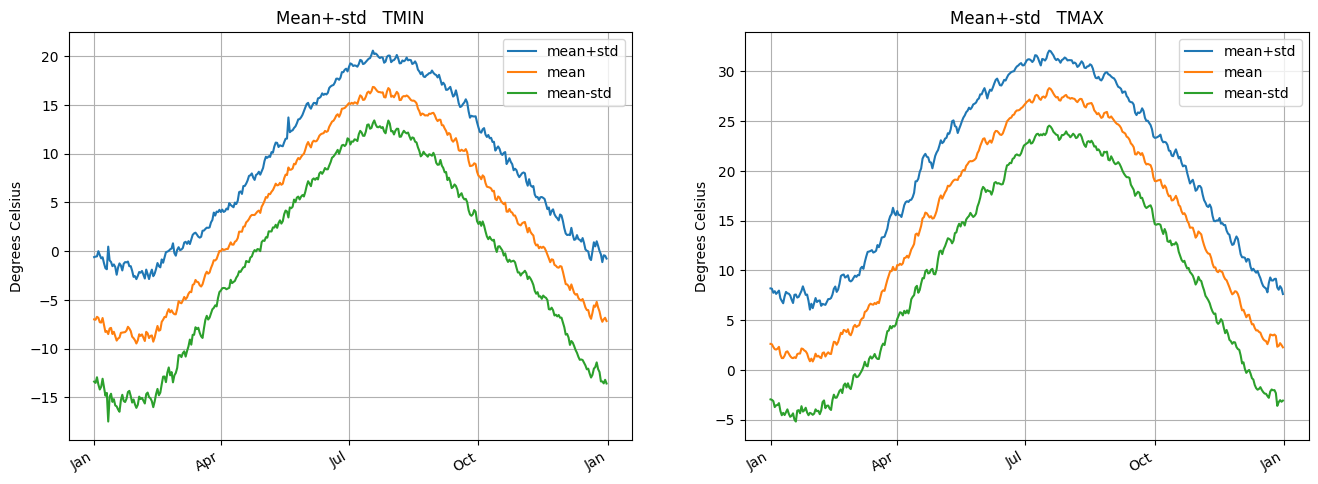

In [38]:
plot_pair(['TMIN','TMAX'],plot_mean_std)

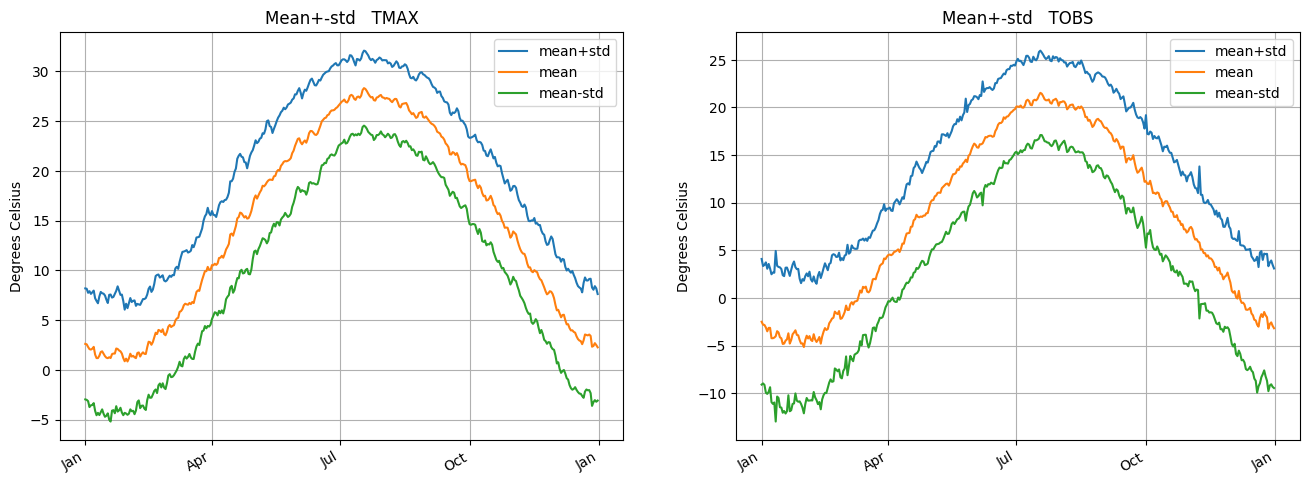

In [39]:
plot_pair(['TMAX','TOBS'],plot_mean_std)

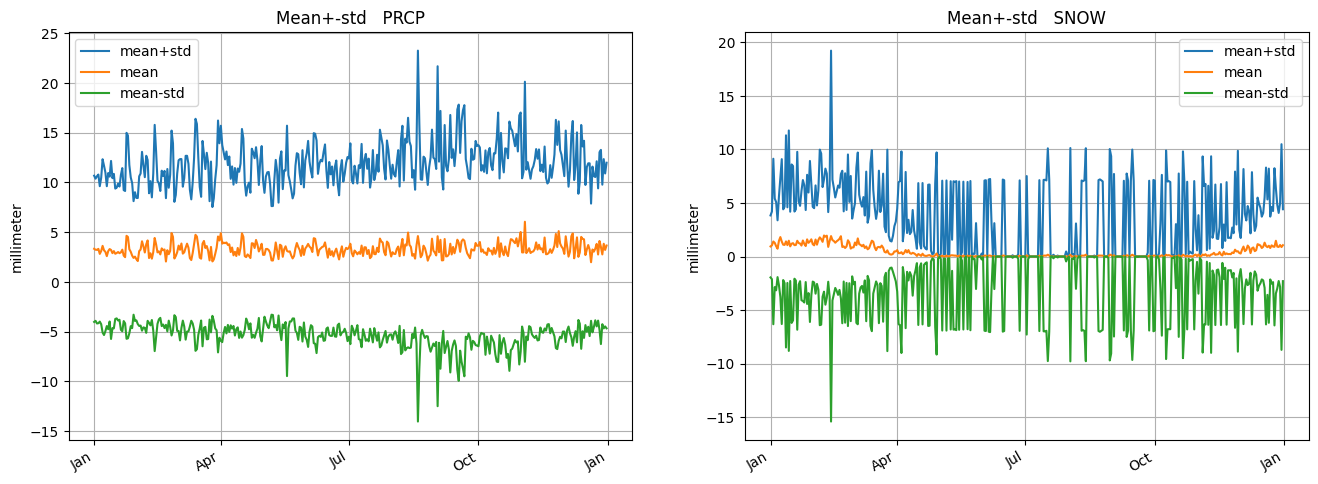

In [40]:
plot_pair(['PRCP','SNOW'],plot_mean_std)

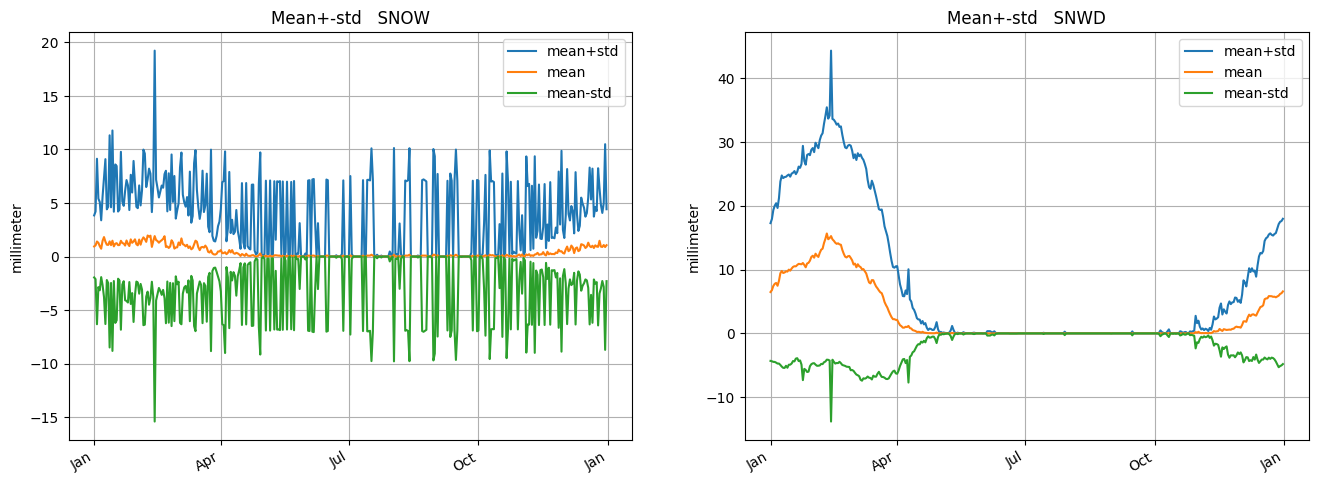

25/04/30 18:39:11 ERROR StandaloneSchedulerBackend: Application has been killed. Reason: Master removed our application: KILLED
25/04/30 18:39:11 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exiting due to error from cluster scheduler: Master removed our application: KILLED
	at org.apache.spark.errors.SparkCoreErrors$.clusterSchedulerError(SparkCoreErrors.scala:218)
	at org.apache.spark.scheduler.TaskSchedulerImpl.error(TaskSchedulerImpl.scala:923)
	at org.apache.spark.scheduler.cluster.StandaloneSchedulerBackend.dead(StandaloneSchedulerBackend.scala:154)
	at org.apache.spark.deploy.client.StandaloneAppClient$ClientEndpoint.markDead(StandaloneAppClient.scala:262)
	at org.apache.spark.deploy.client.StandaloneAppClient$ClientEndpoint$$anonfun$receive$1.applyOrElse(StandaloneAppClient.scala:169)
	at org.apache.spark.rpc.netty.Inbox.$anonfun$process$1(Inbox.scala:115)
	at org.apache.spark.rpc.netty.Inbox.safelyCall(Inbox.scala:213)
	at org.apache.spark.rpc.netty.Inbox.proce

In [41]:
plot_pair(['SNOW', 'SNWD'],plot_mean_std)